# Modelos - Detección de Fraude

In [ ]:
# Importamos librerias a utilizar
import pandas as pd
import numpy as np
import seaborn as sns
import time
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
import os
import re
from joblib import dump, load
import joblib
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real
# KNN
from sklearn.neighbors import KNeighborsClassifier
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Bayesian Classification
from sklearn.naive_bayes import GaussianNB
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Random Forest
from sklearn.ensemble import RandomForestClassifier
# XGBoost
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
# SVR
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
# MLP
from sklearn.neural_network import MLPClassifier

In [117]:
# importamos los datos
filename = 'data_final.csv'
train_data = pd.read_csv(filename)

In [118]:
# Se dividen los datos en el conjunto de entrenamiento y prueba
y = train_data['isFraud']
x = train_data.drop(columns=['isFraud']) # anexar base de datos de JESÚS.
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=100,stratify=y)

## 1. KNN

### Ajuste del Modelo

In [96]:
# Pipeline del modelo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [97]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_knn = {
    'knn__n_neighbors': Categorical([3, 5, 10]),
    'knn__weights': Categorical(['uniform', 'distance'])
}

In [ ]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros de KNN
bayes_knn = BayesSearchCV(
    estimator=pipe_knn,
    search_spaces=search_spaces_knn,
    n_iter=25,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

start_time_knn = time.time()
bayes_knn.fit(x_train, y_train)
end_time_knn = time.time()

# Guardar el modelo
joblib.dump(bayes_knn.best_estimator_, 'bayes_knn.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros de KNN: {bayes_knn.best_params_}")
print(f"Mejor puntuación de KNN: {bayes_knn.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_knn - start_time_knn, 4)}")

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'distance'] before, using random point [3, 'distance']
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'distance'] before, using random point [3, 'uniform']
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'uniform'] before, using random point [10, 'distance']
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 'distance'] before, using random point [3, 'uniform']
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The obj

Mejores parámetros de Random Forest: OrderedDict([('knn__n_neighbors', 10), ('knn__weights', 'distance')])
Mejor puntuación de Random Forest: 0.764789966072915
Tiempo de cómputo (s): : 3580.708


### Forecast Accuracy

In [112]:
# Se carga el mejor modelo
bayes_knn = joblib.load('bayes_knn.pkl')

In [113]:
# Se hacen las predicciones
y_pred_knn = bayes_knn.predict(x_test)
y_pred_proba_knn = bayes_knn.predict_proba(x_test)[:, 1]

In [115]:
# Se calculan las metricas
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

# Se muestran los resultados en un dataframe
resultados_knn = pd.DataFrame({
    'Precision': [f"{precision_knn:.2f}"],
    'Recall': [f"{recall_knn:.2f}"],
    'Accuracy': [f"{accuracy_knn:.2f}"],
    'F1-Score': [f"{f1_knn:.2f}"],
    'AUC': [f"{auc_knn:.2f}"]
})

print("Métricas para el modelo KNN:")
display(resultados_knn)

Métricas para el modelo KNN:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.65,0.26,0.97,0.38,0.77


* Vemos que el modelo de KNN tiene una precision del 0.65 ósea que de todas las transacciones que el modelo predijo como fraude, el 65% realmente fueron fraude. Mientras que solo detectó correctamente el 26% de todos los fraudes reales, lo cual es bastante bajo. El AUC de 0.77 nos indica que el modelo tiene algo de poder discriminativo, pero aún puede mejorar mucho, en especial para detectar correctamente el fraude.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

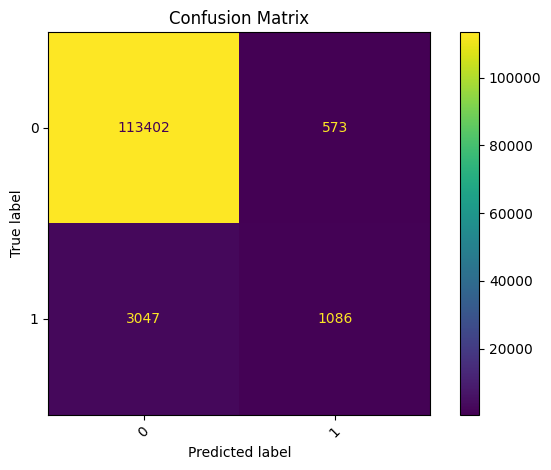

In [103]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Como se menciono anteriormente el modelo no detecta correctamente el fraude, de los 4133 fraudes que hubo solo detecto 1086 de ellos, como se ve en la matriz.

## 2. Logistic Regression

### Ajuste del Modelo

In [146]:
# Pipeline del modelo
pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),### Ajuste del Modelo
    ('logreg', LogisticRegression(solver='saga', class_weight='balanced'))  # solver saga permite elasticnet
])


In [147]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_lg = {
    'logreg__penalty': Categorical(['l1', 'l2', 'elasticnet']),
    'logreg__C': Real(1e-4, 10.0, prior='log-uniform'),
    'logreg__l1_ratio': Real(0.0, 1.0)  # Solo se usa si penalty='elasticnet'
}

In [148]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros de Logistic Regression
bayes_logreg = BayesSearchCV(
    estimator=pipe_logreg,
    search_spaces=search_spaces_lg,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

start_time_lg = time.time()
bayes_logreg.fit(x_train, y_train)
end_time_lg = time.time()

# Guardar el modelo
joblib.dump(bayes_logreg.best_estimator_, 'bayes_logreg.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros Logistic Regressión: {bayes_logreg.best_params_}")
print(f"Mejor puntuación de Logistic Regressión: {bayes_logreg.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_lg - start_time_lg, 4)}")

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Mejores parámetros Logistic Regressión: OrderedDict([('logreg__C', 4.895835030339793), ('logreg__l1_ratio', 0.049430081128050044), ('logreg__penalty', 'l1')])
Mejor puntuación de Logistic Regressión: 0.733739187179882
Tiempo de cómputo (s): : 596.7407


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Forecast Accuracy

In [153]:
# Se carga el mejor modelo
bayes_logreg = joblib.load('bayes_logreg.pkl')

In [154]:
# Se hacen las predicciones
y_pred_logreg = bayes_logreg.predict(x_test)
y_pred_proba_logreg = bayes_logreg.predict_proba(x_test)[:, 1]

In [155]:
# Se calculan las metricas
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)


# Se muestran los resultados en un dataframe
resultados_logreg = pd.DataFrame({
    'Precision': [f"{precision_logreg:.2f}"],
    'Recall': [f"{recall_logreg:.2f}"],
    'Accuracy': [f"{accuracy_logreg:.2f}"],
    'F1-Score': [f"{f1_logreg:.2f}"],
    'AUC': [f"{auc_logreg:.2f}"]
})


print("Métricas para el modelo Logistic Regression:")
display(resultados_logreg)

Métricas para el modelo Logistic Regression:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.08,0.58,0.76,0.14,0.74


* Vemos que el modelo de regresión logística tiene un precision de 0.08, lo cual es bastante bajo, por lo que ocurren muchos falsos positivos. Además, el modelo detecto el 58% de los fraudes reales.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

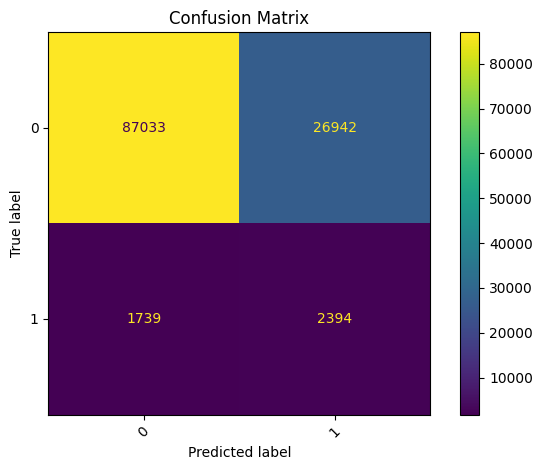

In [156]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Vemos que el modelo detecta correctamente 2394 fraudes de los 4133, aunque hay un gran número de falsos positivos con 26942.

## 3. Bayesian Classification

### Ajuste del Modelo

In [41]:
# Pipeline del modelo
pipe_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

In [42]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_nb = {
    'nb__var_smoothing': Real(1e-11, 1e-7, prior='log-uniform') 
}

In [ ]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros del modelo
bayes_nb = BayesSearchCV(
    estimator=pipe_nb,
    search_spaces=search_spaces_nb,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

start_time_nb = time.time()
bayes_nb.fit(x_train, y_train)
end_time_nb = time.time()

# Guardar el modelo
joblib.dump(bayes_nb.best_estimator_, 'bayes_nb.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros de Bayesian Classification: {bayes_nb.best_params_}")
print(f"Mejor puntuación de Bayesian Classification: {bayes_nb.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_nb - start_time_nb, 4)}")

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1.3500399984179077e-08] before, using random point [5.048760407237832e-10]
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5.882490226719084e-09] before, using random point [2.760837137758653e-08]
  warnings.warn(


Mejores parámetros de Random Forest: OrderedDict([('nb__var_smoothing', 1e-07)])
Mejor puntuación de Random Forest: 0.7061525863848613
Tiempo de cómputo (s): : 19.0312


### Forecast Accuracy

In [123]:
# Se carga el mejor modelo
bayes_nb = joblib.load('bayes_nb.pkl')

In [124]:
# Se hacen las predicciones
y_pred_nb = bayes_nb.predict(x_test)
y_pred_proba_nb = bayes_nb.predict_proba(x_test)[:, 1]

In [125]:
# Se calculan las metricas
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_pred_proba_nb)

# Se muestran los resultados en un dataframe
resultados_nb = pd.DataFrame({
    'Precision': [f"{precision_nb:.2f}"],
    'Recall': [f"{recall_nb:.2f}"],
    'Accuracy': [f"{accuracy_nb:.2f}"],
    'F1-Score': [f"{f1_nb:.2f}"],
    'AUC': [f"{auc_nb:.2f}"]
})

print("Métricas para el modelo Bayesian Classification:")
display(resultados_nb)

Métricas para el modelo Bayesian Classification:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.04,0.92,0.22,0.08,0.71


* Vemos que el modelo de clasificación bayesiana tiene mucha sensibilidad para los fraudes, clasifica casi todo como clase 1 (fraude), por lo que el recall es del 0.92, pero esto genera que la precisión sea muy baja del 0.04, por lo que hay muchos falsos positivos.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

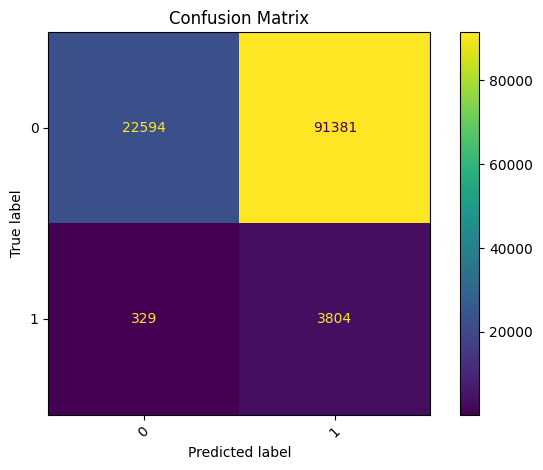

In [126]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Vemos en la matriz que casi todo lo predice como clase 1, por lo que hay muchos falsos positivos 91381.

## 4. Decision Tree

### Ajuste del Modelo

In [51]:
# Pipeline del modelo
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

In [52]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_dt = {
    'dt__max_depth': Integer(3, 30),
    'dt__min_samples_split': Integer(2, 20),
    'dt__min_samples_leaf': Integer(1, 20),
    'dt__criterion': Categorical(['gini', 'entropy', 'log_loss'])
}

In [ ]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros de Decision Tree
bayes_dt = BayesSearchCV(
    estimator=pipe_dt,
    search_spaces=search_spaces_dt,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

start_time_dt = time.time()
bayes_dt.fit(x_train, y_train)
end_time_dt = time.time()

# Guardar el modelo
joblib.dump(bayes_dt.best_estimator_, 'bayes_dt.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros de Decision Tree: {bayes_dt.best_params_}")
print(f"Mejor puntuación de Decision Tree: {bayes_dt.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_dt - start_time_dt, 4)}")

Mejores parámetros de Random Forest: OrderedDict([('dt__criterion', 'log_loss'), ('dt__max_depth', 9), ('dt__min_samples_leaf', 20), ('dt__min_samples_split', 2)])
Mejor puntuación de Random Forest: 0.8078653155579131
Tiempo de cómputo (s): : 72.2882


### Forecast Accuracy

In [127]:
# Se carga el mejor modelo
bayes_dt = joblib.load('bayes_dt.pkl')

In [128]:
# Se hacen las predicciones
y_pred_dt = bayes_dt.predict(x_test)
y_pred_proba_dt = bayes_dt.predict_proba(x_test)[:, 1]

In [129]:
# Se calculan las métricas
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

# Se muestran los resultados en un dataframe
resultados_dt = pd.DataFrame({
    'Precision': [f"{precision_dt:.2f}"],
    'Recall': [f"{recall_dt:.2f}"],
    'Accuracy': [f"{accuracy_dt:.2f}"],
    'F1-Score': [f"{f1_dt:.2f}"],
    'AUC': [f"{auc_dt:.2f}"]
})

print("Métricas para el modelo Decision Tree:")
display(resultados_dt)

Métricas para el modelo Decision Tree:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.72,0.11,0.97,0.19,0.81


* El modelo de árbol de decisión detecta pocos fraudes correctamente, recall del 0.11, aunque tiene una alta precision, ya que, de las transacciones predichas como fraude, el 72% realmente fueron fraude.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

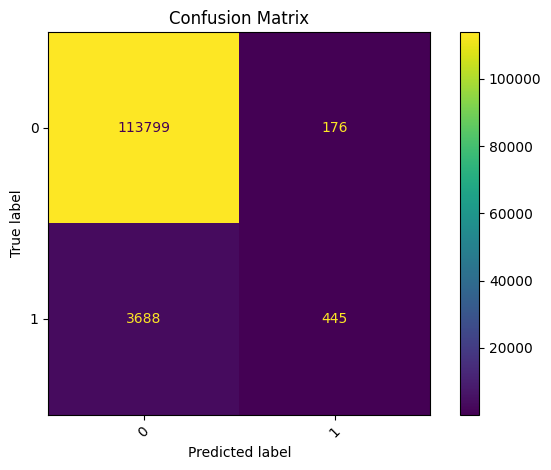

In [130]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Vemos que hubo 3688 falsos negativos por lo que el modelo no predice correctamente cuando hubo un fraude.

## 5. Random Forest

### Ajuste del Modelo

In [62]:
# Pipeline del modelo
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),  # opcional para Random Forest
    ('rf', RandomForestClassifier(random_state=42))
])

In [63]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_rf = {
    'rf__n_estimators': Categorical([50, 100, 200]),
    'rf__max_depth': Categorical([3, 5, 10, 20, 25])
}

In [64]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros de Random Forest
bayes_rf = BayesSearchCV(
    estimator=pipe_rf,
    search_spaces=search_spaces_rf,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

start_time_rf = time.time()
bayes_rf.fit(x_train, y_train)
end_time_rf = time.time()

# Guardar el modelo
joblib.dump(bayes_rf.best_estimator_, 'bayes_rf.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros de Random Forest: {bayes_rf.best_params_}")
print(f"Mejor puntuación de Random Forest: {bayes_rf.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_rf - start_time_rf, 4)}")

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [20, 100] before, using random point [5, 50]
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [3, 200] before, using random point [5, 50]
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [25, 200] before, using random point [20, 200]
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [20, 100] before, using random point [5, 50]
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [3, 100] before, usin

Mejores parámetros de Random Forest: OrderedDict([('rf__max_depth', 25), ('rf__n_estimators', 200)])
Mejor puntuación de Random Forest: 0.8629955946397677
Tiempo de cómputo (s): : 1140.3264


### Forecast Accuracy

In [131]:
# Se carga el mejor modelo
bayes_rf = joblib.load('bayes_rf.pkl')

In [132]:
# Se hacen las predicciones
y_pred_rf = bayes_rf.predict(x_test)
y_pred_proba_rf = bayes_rf.predict_proba(x_test)[:, 1]

In [134]:
# Se calculan las métricas
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# Se muestran los resultados en un dataframe
resultados_rf = pd.DataFrame({
    'Precision': [f"{precision_rf:.2f}"],
    'Recall': [f"{recall_rf:.2f}"],
    'Accuracy': [f"{accuracy_rf:.2f}"],
    'F1-Score': [f"{f1_rf:.2f}"],
    'AUC': [f"{auc_rf:.2f}"]
})

print("Métricas para el modelo Random Forest:")
display(resultados_rf)

Métricas para el modelo Random Forest:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.90,0.25,0.97,0.39,0.87


* Vemos que para el modelo de Random Forest la precisión es bastante alta con 0.9, cuando predice fraude casi siempre acierta. Aun así, hay muchos falsos negativos, el modelo no predice cuando hay fraude correctamente, ya que el recall es de 0.25. El AUC nos da un valor de 0.87, lo que indica que en general hay una buena discriminación.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

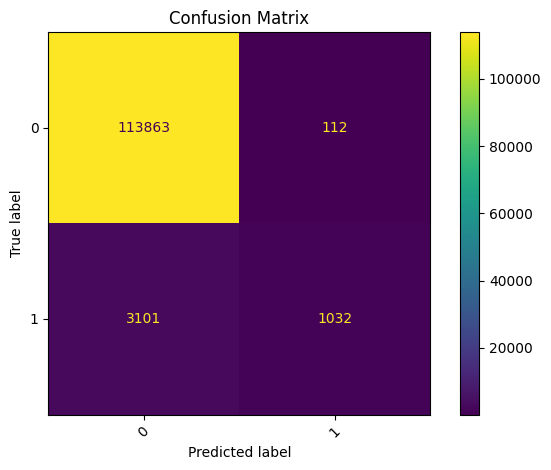

In [135]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* En la matriz de confusión vemos muchos falsos negativos, con 3101 y pocos falsos positivos con 112.

## 6. XGBoost

### Ajuste del Modelo

In [74]:
# # Pipeline del modelo XGBoost
from imblearn.pipeline import Pipeline

pipe_xgb_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
])

In [75]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_xgb = {
    'xgb__n_estimators': Categorical([50, 100, 200]),
    'xgb__max_depth': Integer(3, 10),
    'xgb__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
}

In [ ]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros de XGBoost
bayes_xgb = BayesSearchCV(
    estimator=pipe_xgb_smote,
    search_spaces=search_spaces_xgb,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)

start_time_xgb = time.time()
bayes_xgb.fit(x_train, y_train)
end_time_xgb = time.time()

# Guardar el modelo
joblib.dump(bayes_xgb.best_estimator_, 'bayes_xgb.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros de XGBoost: {bayes_xgb.best_params_}")
print(f"Mejor puntuación de XGBoost: {bayes_xgb.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_xgb - start_time_xgb, 4)}")

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Mejores parámetros de Random Forest: OrderedDict([('xgb__learning_rate', 0.29999999999999993), ('xgb__max_depth', 10), ('xgb__n_estimators', 200)])
Mejor puntuación de Random Forest: 0.8265115437144583
Tiempo de cómputo (s): : 382.4991


### Forecast Accuracy

In [136]:
# Se carga el mejor modelo  
bayes_xgb = joblib.load('bayes_xgb.pkl')

In [137]:
# Se hacen las predicciones
y_pred_xgb = bayes_xgb.predict(x_test)
y_pred_proba_xgb = bayes_xgb.predict_proba(x_test)[:, 1]

In [139]:
# Se calculan las métricas
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# Se muestran los resultados en un dataframe
resultados_xgb = pd.DataFrame({
    'Precision': [f"{precision_xgb:.2f}"],
    'Recall': [f"{recall_xgb:.2f}"],
    'Accuracy': [f"{accuracy_xgb:.2f}"],
    'F1-Score': [f"{f1_xgb:.2f}"],
    'AUC': [f"{auc_xgb:.2f}"]
})

print("Métricas para el modelo XGBoost:")
display(resultados_xgb)

Métricas para el modelo XGBoost:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.38,0.41,0.96,0.39,0.83


* Para el modelo de XGBoost la precisión es de 0.38 y el recall de 0.41, ambos relativamente bajos por lo que el modelo tiene dificultad para predecir la clase positiva, es decir los fraudes. Aun así, el AUC de 0.83 indica que el modelo distingue relativamente bien entre las clases.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

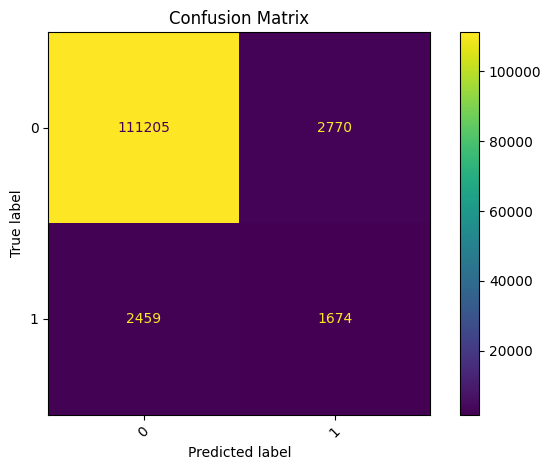

In [140]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Como se menciono anteriormente hay relativamente altos falsos negativos con 2459 y falsos positivos con 2770.

## 7. SVR

### Ajuste del Modelo

In [186]:
# Pipeline del modelo
from imblearn.pipeline import Pipeline

pipe_svm = Pipeline([
    ('smote', SMOTE(random_state=42, n_jobs=-1)),
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(max_iter=10000, random_state=42))
])

In [187]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_svm = {
    'svm__C': Real(0.1, 10, prior='log-uniform')
}

In [188]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros de SVM
bayes_svm = BayesSearchCV(
    estimator=pipe_svm,
    search_spaces=search_spaces_svm,
    n_iter=10,                # Iteraciones reducidas
    scoring='roc_auc',
    cv=3,                     # Menos validación cruzada
    n_jobs=-1,
    random_state=42,
    verbose=0
)

start_time_svm = time.time()
bayes_svm.fit(x_train, y_train)
end_time_svm = time.time()

# Guardar el modelo
joblib.dump(bayes_svm.best_estimator_, 'bayes_svm.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros de Random Forest: {bayes_svm.best_params_}")
print(f"Mejor puntuación de Random Forest: {bayes_svm.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_svm - start_time_svm, 4)}")

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


Mejores parámetros de Random Forest: OrderedDict([('svm__C', 8.146216961026964)])
Mejor puntuación de Random Forest: 0.7129074530508058
Tiempo de cómputo (s): : 52.5863


### Forescast Accuracy

In [193]:
# Se carga el mejor modelo
bayes_svm = joblib.load('bayes_svm.pkl')

In [194]:
# Se hacen las predicciones
y_pred_svm = bayes_svm.predict(x_test)
y_score_svm = bayes_svm.decision_function(x_test)  # <= usamos esto para AUC

In [196]:
# Se calculan las métricas
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_score_svm)

# Se muestran los resultados en un dataframe
resultados_svm = pd.DataFrame({
    'Precision': [f"{precision_svm:.2f}"],
    'Recall': [f"{recall_svm:.2f}"],
    'Accuracy': [f"{accuracy_svm:.2f}"],
    'F1-Score': [f"{f1_svm:.2f}"],
    'AUC': [f"{auc_svm:.2f}"]
})

print("Métricas SVM:")
display(resultados_svm)

Métricas SVM:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.13,0.24,0.92,0.16,0.72


* El modelo SVM tiene una precision de 0.13, las cuales son bajas lo que indica que de las predicciones de fraude hechas pocas son correctas. Y tiene un recall de 0.24, lo que nos indica que esta encontrando pocos fraudes reales.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

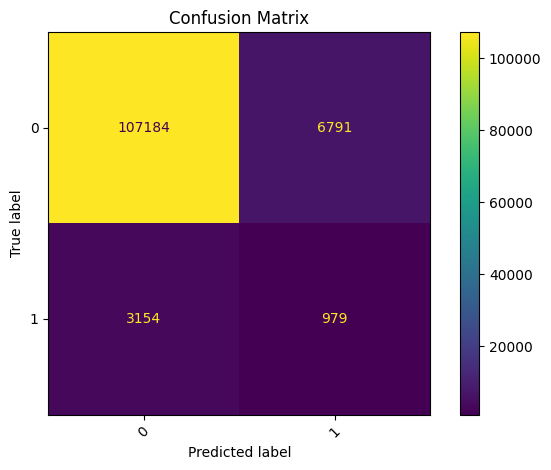

In [197]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Vemos que en la matriz de confusión hay muchos falsos negativos con 3154 y falsos positivos con 6791.

## 8. MLP

### Ajuste del Modelo

In [82]:
# Pipeline del modelo
from imblearn.pipeline import Pipeline

pipe_mlp = Pipeline([
    ('smote', SMOTE(random_state=42, n_jobs=-1)),
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=100, random_state=42))
])

In [83]:
# Espacio de búsqueda para BayesSearchCV
search_spaces_mlp = {
    'mlp__alpha': Real(1e-3, 1e-2, prior='log-uniform'),  # Rango optimizado de alpha
}

In [ ]:
# Realizar BayesSearchCV para encontrar los mejores hiperparámetros de SVM
bayes_mlp = BayesSearchCV(
    estimator=pipe_mlp,
    search_spaces=search_spaces_mlp,
    n_iter=10,        # Menos iteraciones para una prueba más rápida
    scoring='roc_auc',
    cv=3,             # Menos folds para acelerar
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Medir tiempo de entrenamiento
start_time_mlp = time.time()
bayes_mlp.fit(x_train, y_train)
end_time_mlp = time.time()

# Guardar el modelo
joblib.dump(bayes_mlp.best_estimator_, 'bayes_mlp.pkl')

# Imprimir los mejores parámetros, el redimiento y el tiempo de computo
print(f"Mejores parámetros de MLP: {bayes_mlp.best_params_}")
print(f"Mejor puntuación de MLP: {bayes_mlp.best_score_}")
print(f"Tiempo de cómputo (s): : {round(end_time_mlp - start_time_mlp, 4)}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


Mejores parámetros de Random Forest: OrderedDict([('mlp__alpha', 0.006303089031548757)])
Mejor puntuación de Random Forest: 0.788146887921711
Tiempo de cómputo (s): : 1609.2882


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


### Forecast Accuracy

In [141]:
# Se carga el mejor modelo
bayes_mlp = joblib.load('bayes_mlp.pkl')

In [142]:
# Se hacen las predicciones
y_pred_mlp = bayes_mlp.predict(x_test)
y_pred_proba_mlp = bayes_mlp.predict_proba(x_test)[:, 1]

In [143]:
# Se calculan las métricas
precision_mlp = precision_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)

# Se muestran los resultados en un dataframe
resultados_mlp = pd.DataFrame({
    'Precision': [f"{precision_mlp:.2f}"],
    'Recall': [f"{recall_mlp:.2f}"],
    'Accuracy': [f"{accuracy_mlp:.2f}"],
    'F1-Score': [f"{f1_mlp:.2f}"],
    'AUC': [f"{auc_mlp:.2f}"]
})

print("Métricas MLP:")
display(resultados_mlp)

Métricas MLP:


,Precision,Recall,Accuracy,F1-Score,AUC
0,0.17,0.49,0.90,0.25,0.80


* Las métricas del modelo MLP muestran que su precisión es de 0.17 lo que indica que clasifica muchos falsos positivos y su recall es de 0.49, por lo que logra captar casi la mitad de los verdaderos positivos. El AUC de 0.8 indica una razonable capacidad de discriminación entre clases.

### Matriz de confusión

<Figure size 600x600 with 0 Axes>

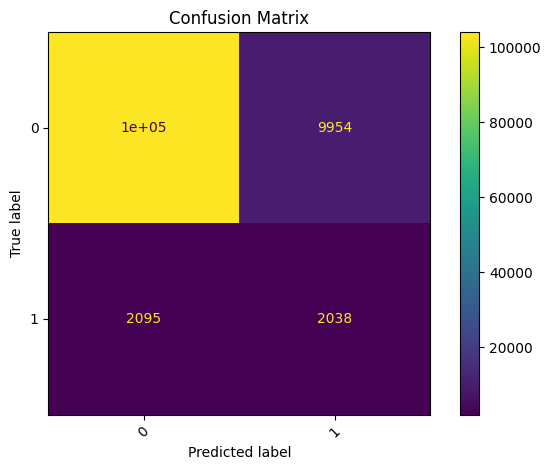

In [88]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))
disp.plot(include_values=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* En la matriz de confusión vemos que casi la mitad de los fraudes fueron clasificados correctamente y la otra mitad no.

## Conclusión

* De entre todos los modelos vemos que el que tuvo mejor precision fue el modelo de random forest, el de mejor recall fue el clasificador bayesiano, los de mejor accuracy fueron KNN, Logistic regression y Random Forest, los de mejor F1-score fueron Random Forest y XGBoost. El modelo que tuvo el mejor AUC fue Random Forest, seguido por XGBoost y luego por Decision tree, por lo que en general los modelos basados en arboles de decisión tuvieron el mejor desempeño.

* De todos los modelos Random Forest parece ser el mejor modelo base, con un tiempo de computo razonable. El modelo que le sigue es el XGBoost el cual también presento métricas relativamente buenas y tuvo un tiempo de computo mejor casi 3 veces menor al de Random Forest. 

| Model                   | Precision | Recall | Accuracy | F1-Score | AUC  | Training Time (sec) |
|--------------------------|-----------|--------|----------|----------|------|---------------------|
| K-NN                     | 0.65      | 0.26   | 0.97     | 0.38     | 0.77 | 3580.71             |
| Logistic Regression      | 0.08      | 0.58   | 0.76     | 0.14     | 0.74 | 596.74              |
| Bayesian Classification  | 0.04      | 0.92   | 0.22     | 0.08     | 0.71 | 19.03               |
| Decision Tree            | 0.72      | 0.11   | 0.97     | 0.19     | 0.81 | 72.29               |
| Random Forest            | 0.90      | 0.25   | 0.97     | 0.39     | 0.87 | 1140.33             |
| XGBoost                  | 0.38      | 0.41   | 0.96     | 0.39     | 0.83 | 382.50              |
| SVM                      | 0.13      | 0.24   | 0.92     | 0.16     | 0.72 | 52.59               |
| MLP                      | 0.17      | 0.49   | 0.90     | 0.25     | 0.80 | 1609.29             |